<a href="https://colab.research.google.com/github/gettokeroro/DADS5001_MINI_PROJECT/blob/main/Kade_Job_Application_Analysis_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Job Application Analysis (LinkedIn Job Postings 2023–2024)

**EN:** This notebook follows a step-by-step workflow:  
Data loading → Data understanding (EDA) → Data cleaning & transformation → Analysis (Remote, Salary, Skills) → Key findings

**TH:** โน้ตบุ๊กนี้ทำตามลำดับขั้นตอนดังนี้:  
โหลดข้อมูล → ทำความเข้าใจข้อมูล (EDA) → ทำความสะอาด/แปลงข้อมูล → วิเคราะห์ (Remote/เงินเดือน/Skills) → สรุปผล

**Data Source:** Kaggle dataset “arshkon/linkedin-job-postings” + mapping tables (companies/industries/skills).

In [1]:
# OPTIONAL: Clone repo (ใช้เมื่อคุณมี dataset/ หรือ notebook ใน GitHub)
!git clone https://github.com/gettokeroro/DADS5001_MINI_PROJECT.git
%cd DADS5001_MINI_PROJECT
!ls

Cloning into 'DADS5001_MINI_PROJECT'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 83 (delta 26), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 13.13 MiB | 4.99 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/DADS5001_MINI_PROJECT
dataset				Kade_Job_Application_Analysis.ipynb  README.md
Job_Application_Analysis.ipynb	notebooks


## Setup

**EN:** Install/upgrade required packages and import libraries.  
**TH:** ติดตั้ง/อัปเดตแพ็กเกจที่จำเป็น และ import ไลบรารีที่ใช้

In [2]:
!pip -q install -U kagglehub

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
from kagglehub import KaggleDatasetAdapter

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 5.9 MB/s eta 0:00:00


## Data Loading: postings.csv (Main Table)

**EN:** We load the main job postings table (`postings.csv`) into a pandas DataFrame (`df`).  
**TH:** โหลดตารางหลัก `postings.csv` เข้าสู่ DataFrame (`df`) ซึ่งเป็นข้อมูลระดับ “งาน” (job-level)

In [3]:
def load_csv_from_kaggle_or_local(file_name, local_path=None, dataset_slug="arshkon/linkedin-job-postings"):
    """
    Try Kagglehub first. If fails and local_path is provided and exists, load local.
    """
    try:
        df_ = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, dataset_slug, file_name)
        return df_
    except Exception as e:
        if local_path and os.path.exists(local_path):
            return pd.read_csv(local_path)
        raise e

# ถ้าคุณมีไฟล์ใน repo: dataset/postings.csv ให้ระบุ local_path ได้
df = load_csv_from_kaggle_or_local("postings.csv", local_path="dataset/postings.csv")

display(df.head())
print("Shape:", df.shape)

Using Colab cache for faster access to the 'linkedin-job-postings' dataset.


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,Full-time,2.0,1.713398e+12,NaN,https://www.linkedin.com/jobs/view/921716/?trk...,NaN,ComplexOnsiteApply,1.715990e+12,NaN,NaN,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,Full-time,NaN,1.712858e+12,NaN,https://www.linkedin.com/jobs/view/1829192/?tr...,NaN,ComplexOnsiteApply,1.715450e+12,NaN,NaN,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,Full-time,NaN,1.713278e+12,NaN,https://www.linkedin.com/jobs/view/10998357/?t...,NaN,ComplexOnsiteApply,1.715870e+12,NaN,NaN,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,Full-time,NaN,1.712896e+12,NaN,https://www.linkedin.com/jobs/view/23221523/?t...,NaN,ComplexOnsiteApply,1.715488e+12,NaN,NaN,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,Full-time,NaN,1.713452e+12,NaN,https://www.linkedin.com/jobs/view/35982263/?t...,NaN,ComplexOnsiteApply,1.716044e+12,NaN,NaN,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


Shape: (123849, 31)


## Data Understanding (EDA)

**EN:** We inspect schema, missing values, and key columns for analysis readiness.  
**TH:** ตรวจโครงสร้างข้อมูล, missing values และคอลัมน์สำคัญ เพื่อเตรียมความพร้อมก่อนวิเคราะห์

In [4]:
df.info()

missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
display(missing.to_frame("missing_%").head(20))

print("Unique job_id:", df["job_id"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

,missing_%
closed_time,99.13
skills_desc,98.03
med_salary,94.93
remote_allowed,87.69
applies,81.17
min_salary,75.94
max_salary,75.94
currency,70.87
compensation_type,70.87
pay_period,70.87


Unique job_id: 123849


## Load Supporting Tables (Mapping / Reference)

**EN:** Besides `postings.csv`, we load supporting tables (companies, industries, skills, job_skills, job_industries, employee_counts).  
These tables enable enrichment via joins (industry names, skill names, company attributes).

**TH:** นอกจาก `postings.csv` เราโหลดตารางเสริม (companies, industries, skills, job_skills, job_industries, employee_counts)  
เพื่อใช้ join เพิ่มข้อมูล เช่น ชื่ออุตสาหกรรม, ชื่อทักษะ, ขนาดบริษัท ฯลฯ

In [5]:
support_files = [
    ("companies.csv", "dataset/companies.csv"),
    ("company_industries.csv", "dataset/company_industries.csv"),
    ("employee_counts.csv", "dataset/employee_counts.csv"),
    ("industries.csv", "dataset/industries.csv"),
    ("skills.csv", "dataset/skills.csv"),
    ("job_skills.csv", "dataset/job_skills.csv"),
    ("job_industries.csv", "dataset/job_industries.csv"),
]

dfs = {}
for kaggle_name, local_name in support_files:
    try:
        dfs[kaggle_name] = load_csv_from_kaggle_or_local(kaggle_name, local_path=local_name)
        print("Loaded:", kaggle_name, "shape=", dfs[kaggle_name].shape)
    except Exception as e:
        print("FAILED:", kaggle_name, "->", e)

df_companies = dfs.get("companies.csv")
df_company_industries = dfs.get("company_industries.csv")
df_employee_counts = dfs.get("employee_counts.csv")
df_industries = dfs.get("industries.csv")
df_skills = dfs.get("skills.csv")
df_job_skills = dfs.get("job_skills.csv")
df_job_industries = dfs.get("job_industries.csv")

Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
FAILED: companies.csv -> 'companies.csv' is not present in the dataset files. You can access the other files of the attached dataset at '/kaggle/input/linkedin-job-postings'
Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
FAILED: company_industries.csv -> 'company_industries.csv' is not present in the dataset files. You can access the other files of the attached dataset at '/kaggle/input/linkedin-job-postings'
Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
FAILED: employee_counts.csv -> 'employee_counts.csv' is not present in the dataset files. You can access the other files of the attached dataset at '/kaggle/input/linkedin-job-postings'
Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
FAILED: industries.csv -> 'industries.csv' is not present in the dataset files. You can access the other files of the attached dataset at '/kagg

## Prepare Data & Cleansing

**EN:** Cleaning and preparation steps:
1) Remove rows with missing `company_id` (to enable company joins)  
2) Convert `original_listed_time` and `expiry` to datetime  
3) Create a robust remote indicator (use `remote_allowed` as primary; fallback to `workplace_type` if available)  
4) Merge job_industries with industries (map IDs → names)  
5) Create:
   - `df_merged` (job-industry level; may have multiple rows per job)
   - `df_job` (job-level; 1 row per job; used for most metrics)
6) For `employee_counts`, keep the latest record per company

**Note (about `work_type`):**
- `work_type` is best used for *employment type* insights (e.g., share of FULL_TIME vs CONTRACT vs PART_TIME).  
- You can also analyze **Remote vs Non-Remote by employment type** (e.g., Remote share in FULL_TIME vs CONTRACT) using `is_remote` + `work_type`.

---

**TH:** ขั้นตอนทำความสะอาด/เตรียมข้อมูล:
1) ตัดแถวที่ไม่มี `company_id` (เพื่อให้ join บริษัทได้)  
2) แปลง `original_listed_time` และ `expiry` เป็น datetime  
3) สร้างตัวชี้ Remote ที่เชื่อถือได้ (ใช้ `remote_allowed` เป็นหลัก และ fallback ไปที่ `workplace_type` ถ้ามี)  
4) รวมตาราง job_industries กับ industries เพื่อได้ชื่ออุตสาหกรรม  
5) สร้าง 2 ตารางสำคัญ:
   - `df_merged` ระดับ job-industry (1 งานมีหลายอุตสาหกรรมได้ → หลายแถว)
   - `df_job` ระดับ job (1 งาน = 1 แถว) ใช้ทำสถิติรวม/แนวโน้ม  
6) employee_counts เลือก record ล่าสุดต่อบริษัท

**หมายเหตุ (เกี่ยวกับ `work_type`):**
- `work_type` เหมาะสำหรับทำ insight เรื่อง *ประเภทการจ้างงาน* เช่น สัดส่วน FULL_TIME vs CONTRACT vs PART_TIME  
- และสามารถดู **Remote vs Non-Remote แยกตามประเภทการจ้างงาน** ได้ (เช่น Remote ใน FULL_TIME มากกว่า CONTRACT ไหม) โดยใช้ `is_remote` + `work_type`


In [6]:
df_clean = df.copy()

# 1) Remove NaN company_id
# TH: ตัดแถวที่ไม่มี company_id (เพื่อให้ join บริษัทได้)
before = len(df_clean)
df_clean = df_clean.dropna(subset=["company_id"])
after = len(df_clean)
print("Dropped rows (company_id NaN):", before - after)

# 2) Convert time fields (epoch ms -> datetime)
# TH: แปลงเวลาจาก epoch (ms) เป็น datetime
# NOTE: your data shows ~1.7e+12 => ms
df_clean["listed_dt"] = pd.to_datetime(df_clean["original_listed_time"], unit="ms", errors="coerce")
df_clean["expiry_dt"] = pd.to_datetime(df_clean["expiry"], unit="ms", errors="coerce")

df_clean["year"] = df_clean["listed_dt"].dt.year
df_clean["month"] = df_clean["listed_dt"].dt.to_period("M").dt.to_timestamp()
df_clean["quarter"] = df_clean["listed_dt"].dt.to_period("Q").astype(str)

# 3) Robust Remote indicator (use remote_allowed as primary)
# ---------------------------------------------------------
# EN: Why not work_type?
# - In this dataset, `work_type` usually means employment type (FULL_TIME / PART_TIME / CONTRACT ...)
# - Remote/Onsite should come from `remote_allowed` (and/or `workplace_type` if available)
#
# TH: ทำไมไม่ใช้ work_type?
# - work_type ในชุดข้อมูลนี้มักหมายถึง "ประเภทการจ้างงาน" (FULL_TIME / PART_TIME / CONTRACT ...)
# - ตัวชี้ Remote ควรมาจาก `remote_allowed` (และ/หรือ `workplace_type` ถ้ามี)

def to_bool_series(s: pd.Series) -> pd.Series:
    """EN/TH: Normalize mixed-type boolean flags (bool/int/str) into True/False."""
    if s.dtype == "bool":
        return s.fillna(False)
    # numeric 0/1
    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(0).astype(int).eq(1)
    # string-like
    return (s.fillna("")
             .astype(str).str.strip().str.lower()
             .isin(["1","true","yes","y","t","remote"]))  # include "remote" as truthy token

# --- detect best remote flag column name (remote_allowed is expected) ---
remote_flag_col = None
for cand in ["remote_allowed", "remoteAllowed", "is_remote", "remote"]:
    if cand in df_clean.columns:
        remote_flag_col = cand
        break

# --- detect workplace type column name (optional fallback / hybrid / onsite) ---
workplace_col = None
for cand in ["workplace_type", "workplaceType", "workplace"]:
    if cand in df_clean.columns:
        workplace_col = cand
        break
if workplace_col is None:
    # any column that contains 'workplace' in its name
    for c in df_clean.columns:
        if "workplace" in str(c).lower():
            workplace_col = c
            break

# Primary: remote_allowed (recommended)
if remote_flag_col is not None:
    df_clean["is_remote"] = to_bool_series(df_clean[remote_flag_col]).astype(bool)

# Fallback: workplace_type (if remote flag missing)
elif workplace_col is not None:
    wp = df_clean[workplace_col].fillna("").astype(str).str.strip().str.lower()
    df_clean["is_remote"] = wp.str.contains(r"\bremote\b")
else:
    # Last resort: if neither exists, keep as False (avoid misleading results)
    df_clean["is_remote"] = False

# Optional: Hybrid / Onsite flags (if workplace_type exists)
if workplace_col is not None:
    wp = df_clean[workplace_col].fillna("").astype(str).str.strip().str.lower()
    df_clean["is_hybrid"] = wp.str.contains("hybrid")
    df_clean["is_onsite"] = wp.str.contains(r"on[-\s]?site|onsite")
else:
    df_clean["is_hybrid"] = False
    df_clean["is_onsite"] = False

# Quick sanity check
cols_to_show = [c for c in ["job_id","work_type",remote_flag_col,workplace_col,"is_remote","is_hybrid","is_onsite"] if c and c in df_clean.columns]
display(df_clean[cols_to_show].head(10))
print("Unique job_id (clean):", df_clean["job_id"].nunique())
print("is_remote dtype:", df_clean["is_remote"].dtype)
print(df_clean["is_remote"].value_counts(dropna=False))

# Extra insight (Work Type):
# EN: work_type = employment type distribution; remote share by work_type
# TH: work_type = สัดส่วนประเภทการจ้างงาน; และดู remote_allowed/is_remote แยกตามประเภทงานจ้างได้
if "work_type" in df_clean.columns:
    print("\nWork type distribution (employment type):")
    display(df_clean["work_type"].fillna("(missing)").value_counts().to_frame("count"))

    remote_by_wt = (df_clean
                    .groupby(df_clean["work_type"].fillna("(missing)"), dropna=False)
                    .agg(
                        total_jobs=("job_id","nunique"),
                        remote_jobs=("is_remote","sum")
                    )
                    .reset_index()
                    .rename(columns={"work_type":"work_type"})
                   )
    remote_by_wt["remote_share"] = remote_by_wt["remote_jobs"] / remote_by_wt["total_jobs"]
    print("\nRemote share by work_type:")
    display(remote_by_wt.sort_values("remote_share", ascending=False))


Dropped rows (company_id NaN): 1717


,job_id,work_type,remote_allowed,is_remote,is_hybrid,is_onsite
0,921716,FULL_TIME,NaN,False,False,False
2,10998357,FULL_TIME,NaN,False,False,False
3,23221523,FULL_TIME,NaN,False,False,False
5,91700727,INTERNSHIP,NaN,False,False,False
6,103254301,CONTRACT,1.0,True,False,False
8,1218575,FULL_TIME,NaN,False,False,False
9,2264355,PART_TIME,NaN,False,False,False
10,9615617,FULL_TIME,NaN,False,False,False
11,11009123,FULL_TIME,NaN,False,False,False
14,69333422,FULL_TIME,1.0,True,False,False


Unique job_id (clean): 122132
is_remote dtype: bool
is_remote
False    107318
True      14814
Name: count, dtype: int64

Work type distribution (employment type):


,count
work_type,
FULL_TIME,97554
CONTRACT,11955
PART_TIME,9488
TEMPORARY,1176
INTERNSHIP,955
VOLUNTEER,555
OTHER,449



Remote share by work_type:


,work_type,total_jobs,remote_jobs,remote_share
0,CONTRACT,11955,3091,0.258553
6,VOLUNTEER,555,117,0.210811
2,INTERNSHIP,955,197,0.206283
3,OTHER,449,54,0.120267
1,FULL_TIME,97554,10771,0.110411
5,TEMPORARY,1176,82,0.069728
4,PART_TIME,9488,502,0.052909


## Merge Job Industries with Industry Names

**EN:** We map `industry_id` to `industry_name` by joining `job_industries` with `industries`.  
**TH:** เรา join `job_industries` กับ `industries` เพื่อแปลงรหัสอุตสาหกรรมให้เป็นชื่ออุตสาหกรรม (`industry_name`)

In [7]:
import os
import pandas as pd

def find_file(filename, start="."):
    for root, _, files in os.walk(start):
        if filename in files:
            return os.path.join(root, filename)
    return None

# 1) ตรวจ type ของตัวแปร (ถ้ามี)
for var in ["df_job_industries", "df_industries"]:
    if var in globals():
        print(var, "->", type(globals()[var]))
    else:
        print(var, "->", "NOT DEFINED")

# 2) หาไฟล์จริงในโฟลเดอร์โปรเจกต์ (รองรับมี subfolder)
targets = ["job_industries.csv", "industries.csv"]
for t in targets:
    path = find_file(t, start=".")
    print(f"FOUND {t}: {path}")

# 3) ถ้าคุณมี dataset/ ให้ดูโครงสร้างคร่าว ๆ
if os.path.exists("dataset"):
    print("\n--- dataset/ (top-level) ---")
    print(os.listdir("dataset")[:50])

df_job_industries -> <class 'NoneType'>
df_industries -> <class 'NoneType'>
FOUND job_industries.csv: ./dataset/jobs/job_industries.csv
FOUND industries.csv: ./dataset/mappings/industries.csv

--- dataset/ (top-level) ---
['mappings', 'jobs', 'companies']


In [8]:
import os
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

def find_file(filename, start="."):
    for root, _, files in os.walk(start):
        if filename in files:
            return os.path.join(root, filename)
    return None

def load_csv_smart(file_name, dataset_slug="arshkon/linkedin-job-postings"):
    # 1) Try Kagglehub
    try:
        df_ = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, dataset_slug, file_name)
        print("Loaded from Kagglehub:", file_name, "shape=", df_.shape)
        return df_
    except Exception as e:
        # 2) Try local search
        path = find_file(file_name, start=".")
        if path:
            df_ = pd.read_csv(path)
            print("Loaded from Local:", path, "shape=", df_.shape)
            return df_
        raise RuntimeError(f"Cannot load {file_name} from Kagglehub or local. Error: {e}")

df_industries = load_csv_smart("industries.csv")
df_job_industries = load_csv_smart("job_industries.csv")

display(df_industries.head())
display(df_job_industries.head())

print("df_industries columns:", df_industries.columns.tolist())
print("df_job_industries columns:", df_job_industries.columns.tolist())

Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
Loaded from Local: ./dataset/mappings/industries.csv shape= (422, 2)
Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
Loaded from Local: ./dataset/jobs/job_industries.csv shape= (164808, 2)


,industry_id,industry_name
0,1,Defense and Space Manufacturing
1,3,Computer Hardware Manufacturing
2,4,Software Development
3,5,Computer Networking Products
4,6,"Technology, Information and Internet"


,job_id,industry_id
0,3884428798,82
1,3887473071,48
2,3887465684,41
3,3887467939,82
4,3887467939,80


df_industries columns: ['industry_id', 'industry_name']
df_job_industries columns: ['job_id', 'industry_id']


In [9]:
df_job_industries_with_names = pd.merge(
    df_job_industries,
    df_industries,
    on="industry_id",
    how="left"
)

display(df_job_industries_with_names.head())
print("job_industries_with_names shape:", df_job_industries_with_names.shape)

,job_id,industry_id,industry_name
0,3884428798,82,Book and Periodical Publishing
1,3887473071,48,Construction
2,3887465684,41,Banking
3,3887467939,82,Book and Periodical Publishing
4,3887467939,80,Advertising Services


job_industries_with_names shape: (164808, 3)


## Create Analysis Tables: df_merged vs df_job

**EN:**  
- `df_merged` = job-industry level table (a job can appear multiple times if it has multiple industries).  
- `df_job` = job-level table (1 row per job_id), safe for totals/trends/salary comparisons.

**TH:**  
- `df_merged` = ตารางระดับ job-industry (1 งานอาจมีหลายอุตสาหกรรม → หลายแถว)  
- `df_job` = ตารางระดับ job (1 job_id = 1 แถว) ใช้ทำสถิติรวม/แนวโน้ม/เงินเดือนอย่างถูกต้อง

In [10]:
# df_merged: may have duplicated job_id (expected)
df_merged = pd.merge(
    df_clean,
    df_job_industries_with_names[["job_id","industry_id","industry_name"]],
    on="job_id",
    how="left"
)

print("df_clean rows:", len(df_clean), "unique job_id:", df_clean["job_id"].nunique())
print("df_merged rows:", len(df_merged), "unique job_id:", df_merged["job_id"].nunique())
print("Extra rows due to multi-industry:", len(df_merged) - df_merged["job_id"].nunique())

# df_job: job-level safe table
df_job = df_clean.drop_duplicates(subset=["job_id"]).copy()
print("df_job rows:", len(df_job), "unique job_id:", df_job["job_id"].nunique())

# Optional: keep industry_names as aggregated list per job (nice for display)
industry_agg = (df_job_industries_with_names
                .dropna(subset=["industry_name"])
                .groupby("job_id")["industry_name"]
                .apply(lambda x: ", ".join(sorted(set(x))))
                .reset_index()
                .rename(columns={"industry_name":"industry_names"}))

df_job = df_job.merge(industry_agg, on="job_id", how="left")
display(df_job[["job_id","industry_names"]].head())

df_clean rows: 122132 unique job_id: 122132
df_merged rows: 158449 unique job_id: 122132
Extra rows due to multi-industry: 36317
df_job rows: 122132 unique job_id: 122132


,job_id,industry_names
0,921716,Real Estate
1,10998357,Restaurants
2,23221523,Law Practice
3,91700727,Non-profit Organization Management
4,103254301,Design Services


## Keep latest employee_counts record per company

**EN:** employee_counts may have multiple records per company over time. We keep the latest record (max `time_recorded`) as the most up-to-date company size signal.  
**TH:** ตาราง employee_counts มีหลาย record ต่อบริษัทตามเวลา เราเก็บ record ล่าสุด (time_recorded มากที่สุด) เพื่อแทน “ขนาดบริษัทล่าสุด”

In [11]:
import os
import pandas as pd

path_ec = "./dataset/companies/employee_counts.csv"
print("cwd:", os.getcwd())
print("exists?", os.path.exists(path_ec), "| path:", path_ec)

df_employee_counts = pd.read_csv(path_ec)
print("df_employee_counts:", df_employee_counts.shape)
display(df_employee_counts.head())

cwd: /content/DADS5001_MINI_PROJECT
exists? True | path: ./dataset/companies/employee_counts.csv
df_employee_counts: (35787, 4)


,company_id,employee_count,follower_count,time_recorded
0,391906,186,32508,1712346173
1,22292832,311,4471,1712346173
2,20300,1053,6554,1712346173
3,3570660,383,35241,1712346173
4,878353,52,26397,1712346173


In [12]:
import pandas as pd
import os

# mappings/
df_industries = pd.read_csv("./dataset/mappings/industries.csv")
df_skills = pd.read_csv("./dataset/mappings/skills.csv")

# jobs/
df_job_industries = pd.read_csv("./dataset/jobs/job_industries.csv")
df_job_skills = pd.read_csv("./dataset/jobs/job_skills.csv")

# companies/
df_companies = pd.read_csv("./dataset/companies/companies.csv")
df_company_industries = pd.read_csv("./dataset/companies/company_industries.csv")
df_employee_counts = pd.read_csv("./dataset/companies/employee_counts.csv")

print("Loaded OK:")
print("df_industries:", df_industries.shape)
print("df_job_industries:", df_job_industries.shape)
print("df_employee_counts:", df_employee_counts.shape)

Loaded OK:
df_industries: (422, 2)
df_job_industries: (164808, 2)
df_employee_counts: (35787, 4)


In [13]:
ec = df_employee_counts.copy()

# Convert epoch seconds -> datetime
ec["time_recorded_dt"] = pd.to_datetime(ec["time_recorded"], unit="s", errors="coerce")

# Keep latest per company_id
ec_latest = (ec.sort_values(["company_id","time_recorded_dt"])
             .drop_duplicates(subset=["company_id"], keep="last")
            )

print("employee_counts rows:", len(ec), "latest rows:", len(ec_latest), "unique companies:", ec_latest["company_id"].nunique())

# Align dtypes for safer merge
df_job["company_id"] = df_job["company_id"].astype("Int64")
ec_latest["company_id"] = ec_latest["company_id"].astype("Int64")

df_job = df_job.merge(
    ec_latest[["company_id","employee_count","follower_count","time_recorded_dt"]],
    on="company_id",
    how="left"
)

display(df_job[["company_id","employee_count","follower_count","time_recorded_dt"]].head())

employee_counts rows: 35787 latest rows: 24473 unique companies: 24473


,company_id,employee_count,follower_count,time_recorded_dt
0,2774458,402.0,2351.0,2024-04-18 03:01:15
1,64896719,15.0,40.0,2024-04-16 14:55:21
2,766262,222.0,2427.0,2024-04-12 04:48:19
3,1481176,22.0,7825.0,2024-04-18 17:04:11
4,81942316,11.0,447.0,2024-04-11 18:46:42


## Location Normalization (USA vs Other)

**EN:** We standardize location into two groups (USA vs Other) using:
1) `fips` (strong USA indicator)  
2) Regex matching for US state abbreviations in `location` for remaining cases

**TH:** เรามาตรฐาน location ให้เหลือ 2 กลุ่ม (USA vs Other) โดยใช้:
1) `fips` เป็นตัวชี้ USA ที่เชื่อถือได้  
2) ใช้ regex ตรวจหา “ตัวย่อรัฐ” ใน `location` สำหรับแถวที่ยังเป็น Other

> Note: Regex uses word boundaries to avoid false positives (e.g., "OR" matching common words).

In [14]:
df_job["location_transformed_refined"] = "Other"
df_job.loc[df_job["fips"].notna(), "location_transformed_refined"] = "USA"

# US state abbreviations + territories (uppercase)
state_abbr = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA","KS","KY","LA","ME","MD","MA",
    "MI","MN","MS","MO","MT","NE","NV","NH","NJ","NM","NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN","TX",
    "UT","VT","VA","WA","WV","WI","WY","DC","PR","GU","VI","AS","MP"
]
pattern = r"\b(" + "|".join(state_abbr) + r")\b"

mask_other = df_job["location_transformed_refined"].eq("Other")
mask_us_loc = df_job["location"].fillna("").str.contains(pattern, case=False, regex=True)

df_job.loc[mask_other & mask_us_loc, "location_transformed_refined"] = "USA"

print(df_job["location_transformed_refined"].value_counts(dropna=False))

/tmp/ipython-input-257/3432650477.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_us_loc = df_job["location"].fillna("").str.contains(pattern, case=False, regex=True)


location_transformed_refined
USA      104234
Other     17898
Name: count, dtype: int64


## 5.1 Overview Metrics by Year

**EN:** We aggregate yearly metrics (distinct companies, distinct job titles, total views, total applies) to understand overall activity trends.  
**TH:** สรุปตัวชี้วัดรายปี (จำนวนบริษัทไม่ซ้ำ, จำนวนชื่อตำแหน่งไม่ซ้ำ, views, applies) เพื่อดูแนวโน้มภาพรวมของตลาด

> We use `df_job` (job-level) to avoid duplication caused by multi-industry joins.

In [15]:
yearly = df_job.groupby("year").agg(
    distinct_company_ids=("company_id","nunique"),
    distinct_job_titles=("title","nunique"),
    total_views=("views","sum"),
    total_applies=("applies","sum"),
    total_jobs=("job_id","nunique")
).reset_index().sort_values("year")

display(yearly)

# Display formatted (keep original numeric for plots)
yearly_disp = yearly.copy()
for c in ["distinct_company_ids","distinct_job_titles","total_views","total_applies","total_jobs"]:
    yearly_disp[c] = yearly_disp[c].fillna(0).astype(int).map(lambda x: f"{x:,}")
display(yearly_disp)

,year,distinct_company_ids,distinct_job_titles,total_views,total_applies,total_jobs
0,2023,2,2,527.0,6.0,2
1,2024,24473,71879,1762635.0,241231.0,122130


,year,distinct_company_ids,distinct_job_titles,total_views,total_applies,total_jobs
0,2023,2,2,527,6,2
1,2024,"24,473","71,879","1,762,635","241,231","122,130"


## 5.2 USA vs Other (Overview)

**EN:** Compare activity metrics between USA vs Other using the normalized location group.  
**TH:** เปรียบเทียบตัวชี้วัดระหว่าง USA vs Other โดยใช้ location ที่จัดกลุ่มแล้ว

In [16]:
loc_metrics = df_job.groupby("location_transformed_refined").agg(
    total_jobs=("job_id","nunique"),
    distinct_company_ids=("company_id","nunique"),
    total_views=("views","sum"),
    total_applies=("applies","sum")
).reset_index()

display(loc_metrics)

loc_metrics_disp = loc_metrics.copy()
for c in ["total_jobs","distinct_company_ids","total_views","total_applies"]:
    loc_metrics_disp[c] = loc_metrics_disp[c].fillna(0).astype(int).map(lambda x: f"{x:,}")
display(loc_metrics_disp)

,location_transformed_refined,total_jobs,distinct_company_ids,total_views,total_applies
0,Other,17898,8047,663341.0,123609.0
1,USA,104234,19709,1099821.0,117628.0


,location_transformed_refined,total_jobs,distinct_company_ids,total_views,total_applies
0,Other,"17,898","8,047","663,341","123,609"
1,USA,"104,234","19,709","1,099,821","117,628"


## Filtered Datasets for Analysis (2024)

**EN:** “Dataset 1–3” refer to filtered subsets for analysis (not raw versions):
- Dataset 1: 2024 & USA
- Dataset 2: 2024 & Other (non-USA)
- Dataset 3: 2024 Overall (All locations)

**TH:** “Dataset 1–3” คือชุดข้อมูลย่อยสำหรับวิเคราะห์ (ไม่ใช่ raw):
- Dataset 1: ปี 2024 เฉพาะ USA
- Dataset 2: ปี 2024 เฉพาะ Other (นอก USA)
- Dataset 3: ปี 2024 รวมทั้งหมด

In [17]:
df_2024_all = df_job[df_job["year"] == 2024].copy()
df_2024_usa = df_2024_all[df_2024_all["location_transformed_refined"] == "USA"].copy()
df_2024_other = df_2024_all[df_2024_all["location_transformed_refined"] == "Other"].copy()

def check_dup(name, d):
    print(name, "| rows:", len(d), "| unique jobs:", d["job_id"].nunique(), "| dup rows:", len(d) - d["job_id"].nunique())

check_dup("2024_all", df_2024_all)
check_dup("2024_usa", df_2024_usa)
check_dup("2024_other", df_2024_other)

display(df_2024_all.head())

2024_all | rows: 122130 | unique jobs: 122130 | dup rows: 0
2024_usa | rows: 104232 | unique jobs: 104232 | dup rows: 0
2024_other | rows: 17898 | unique jobs: 17898 | dup rows: 0


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips,listed_dt,expiry_dt,year,month,quarter,is_remote,is_hybrid,is_onsite,industry_names,employee_count,follower_count,time_recorded_dt,location_transformed_refined
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458,20.0,NaN,17.0,Full-time,2.0,1.713398e+12,NaN,https://www.linkedin.com/jobs/view/921716/?trk...,NaN,ComplexOnsiteApply,1.715990e+12,NaN,NaN,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0,2024-04-17 23:45:08,2024-05-17 23:45:08,2024,2024-04-01,2024Q2,False,False,False,Real Estate,402.0,2351.0,2024-04-18 03:01:15,USA
1,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719,8.0,NaN,45000.0,Full-time,NaN,1.713278e+12,NaN,https://www.linkedin.com/jobs/view/10998357/?t...,NaN,ComplexOnsiteApply,1.715870e+12,NaN,NaN,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0,2024-04-16 14:26:54,2024-05-16 14:26:54,2024,2024-04-01,2024Q2,False,False,False,Restaurants,15.0,40.0,2024-04-16 14:55:21,USA
2,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262,16.0,NaN,140000.0,Full-time,NaN,1.712896e+12,NaN,https://www.linkedin.com/jobs/view/23221523/?t...,NaN,ComplexOnsiteApply,1.715488e+12,NaN,NaN,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0,2024-04-12 04:23:32,2024-05-12 04:23:32,2024,2024-04-01,2024Q2,False,False,False,Law Practice,222.0,2427.0,2024-04-12 04:48:19,USA
3,91700727,Downtown Raleigh Alliance,Economic Development and Planning Intern,Job summary:The Economic Development & Plannin...,20.0,HOURLY,"Raleigh, NC",1481176,9.0,NaN,14.0,Internship,4.0,1.713456e+12,NaN,https://www.linkedin.com/jobs/view/91700727/?t...,NaN,ComplexOnsiteApply,1.716048e+12,NaN,NaN,NaN,1.713456e+12,NaN,0,INTERNSHIP,USD,BASE_SALARY,35360.0,27601.0,37183.0,2024-04-18 16:01:39,2024-05-18 16:01:39,2024,2024-04-01,2024Q2,False,False,False,Non-profit Organization Management,22.0,7825.0,2024-04-18 17:04:11,USA
4,103254301,Raw Cereal,Producer,Company DescriptionRaw Cereal is a creative de...,300000.0,YEARLY,United States,81942316,7.0,NaN,60000.0,Contract,1.0,1.712861e+12,1.0,https://www.linkedin.com/jobs/view/103254301/?...,NaN,SimpleOnsiteApply,1.715453e+12,NaN,NaN,NaN,1.712861e+12,NaN,0,CONTRACT,USD,BASE_SALARY,180000.0,NaN,NaN,2024-04-11 18:43:39,2024-05-11 18:43:39,2024,2024-04-01,2024Q2,True,False,False,Design Services,11.0,447.0,2024-04-11 18:46:42,Other


## 5.3 Industry Analysis (2024)

**EN:** We analyze which industries receive higher attention (views/applies) and have more postings.  
We compare USA vs Other using the job-industry mapping.

**TH:** วิเคราะห์ว่าอุตสาหกรรมไหน “คนดูเยอะ/สมัครเยอะ/ประกาศเยอะ” และเปรียบเทียบ USA vs Other โดยใช้ตารางเชื่อม job-industry

> Industry is many-to-many: one job can belong to multiple industries.  
> We therefore use `nunique(job_id)` when counting postings per industry.

In [18]:
# Use job-industry table for industry-level
df_merged_2024 = df_merged[df_merged["year"] == 2024].copy()

# Attach location group from job-level table (safe)
df_merged_2024 = df_merged_2024.merge(
    df_job[["job_id","location_transformed_refined"]],
    on="job_id",
    how="left",
    suffixes=("","_job")
)

def industry_metrics(sub):
    # n_jobs counts unique job_id to avoid inflation
    return (sub.dropna(subset=["industry_name"])
            .groupby("industry_name")
            .agg(
                n_jobs=("job_id","nunique"),
                total_views=("views","sum"),
                total_applies=("applies","sum"),
            )
            .reset_index()
           )

ind_usa = industry_metrics(df_merged_2024[df_merged_2024["location_transformed_refined"]=="USA"])
ind_other = industry_metrics(df_merged_2024[df_merged_2024["location_transformed_refined"]=="Other"])

display(ind_usa.sort_values("n_jobs", ascending=False).head(10))
display(ind_other.sort_values("n_jobs", ascending=False).head(10))

,industry_name,n_jobs,total_views,total_applies
147,Hospitals and Health Care,16008,96290.0,5326.0
282,Retail,10230,68798.0,3619.0
155,IT Services and IT Consulting,7603,127988.0,22018.0
322,Staffing and Recruiting,7379,58670.0,5865.0
114,Financial Services,6641,92867.0,11777.0
194,Manufacturing,3128,32657.0,3161.0
313,Software Development,3111,65932.0,9952.0
68,Construction,2795,27981.0,1948.0
30,Banking,2415,32135.0,5624.0
145,Hospitality,2190,18778.0,1739.0


,industry_name,n_jobs,total_views,total_applies
139,IT Services and IT Consulting,2409,95787.0,21920.0
278,Software Development,1723,82299.0,16008.0
133,Hospitals and Health Care,1719,50597.0,10223.0
103,Financial Services,1285,41133.0,8160.0
287,Staffing and Recruiting,870,35027.0,6707.0
152,Insurance,760,23149.0,3574.0
293,"Technology, Information and Media",530,36834.0,8320.0
58,Computer and Network Security,496,28331.0,5415.0
61,Construction,490,8228.0,823.0
252,Retail,482,15976.0,3162.0


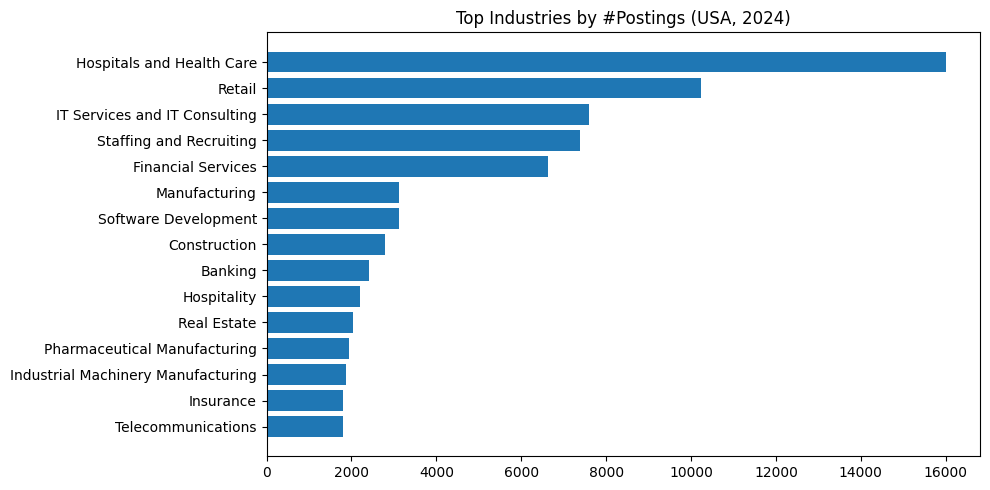

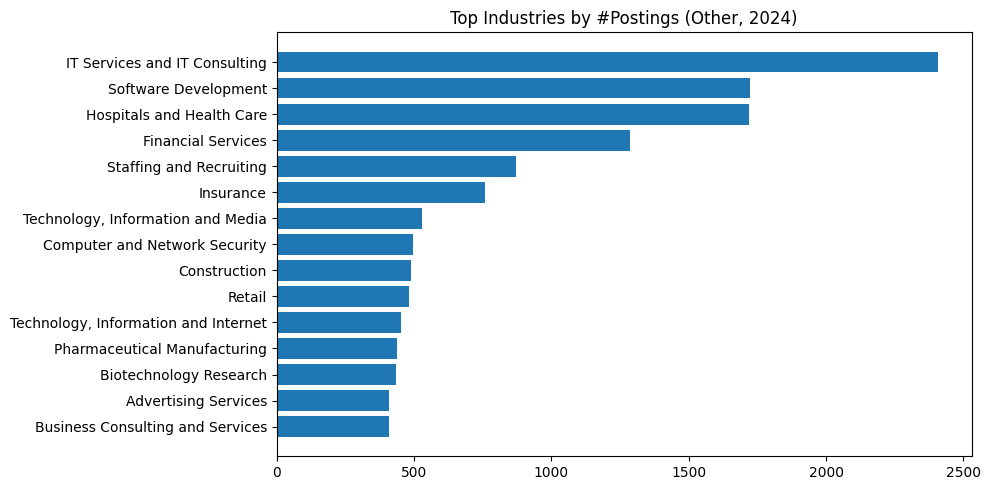

In [19]:
top_n = 15

# Top by postings
plot_usa = ind_usa.sort_values("n_jobs", ascending=False).head(top_n)
plot_other = ind_other.sort_values("n_jobs", ascending=False).head(top_n)

plt.figure(figsize=(10,5))
plt.barh(plot_usa["industry_name"][::-1], plot_usa["n_jobs"][::-1])
plt.title("Top Industries by #Postings (USA, 2024)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.barh(plot_other["industry_name"][::-1], plot_other["n_jobs"][::-1])
plt.title("Top Industries by #Postings (Other, 2024)")
plt.tight_layout()
plt.show()

## 5.4 Remote Trend Over Time (2024)

**EN:** Remote Share = (number of remote postings) / (total postings).  
We analyze monthly and quarterly trends and compare USA vs Other.

**TH:** สัดส่วน Remote = (จำนวนงาน Remote) / (จำนวนงานทั้งหมด)  
วิเคราะห์แนวโน้มรายเดือน/รายไตรมาส และเปรียบเทียบ USA vs Other

> We use `is_remote` derived from `remote_allowed` (primary) for a reliable remote indicator.

,month,total_posts,remote_posts,remote_share
0,2024-01-01,6,2,0.333333
1,2024-02-01,8,2,0.250000
2,2024-03-01,1811,212,0.117062
3,2024-04-01,120305,14598,0.121342


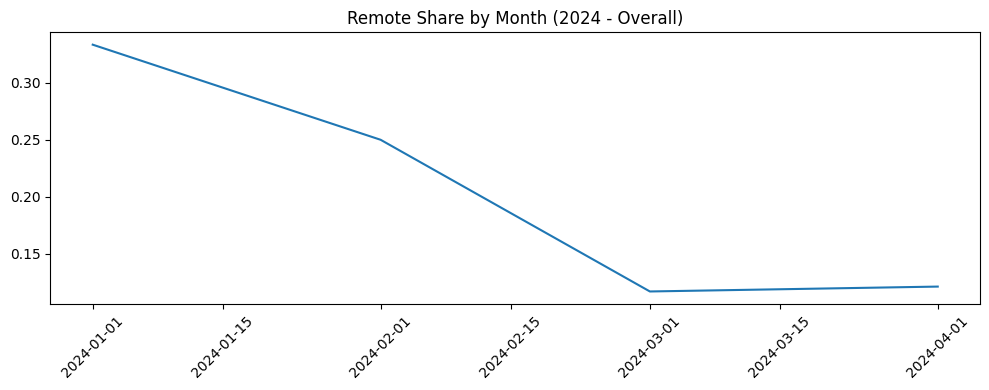

,quarter,total_posts,remote_posts,remote_share
0,2024Q1,1825,216,0.118356
1,2024Q2,120305,14598,0.121342


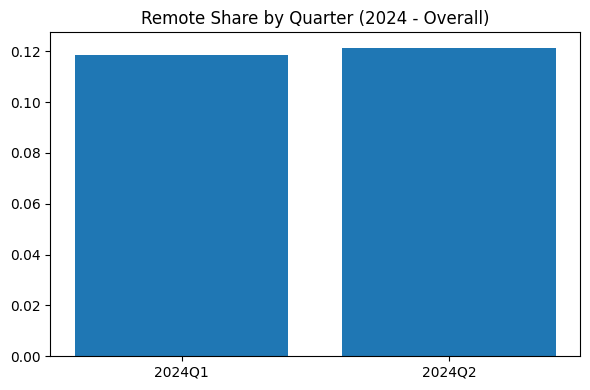

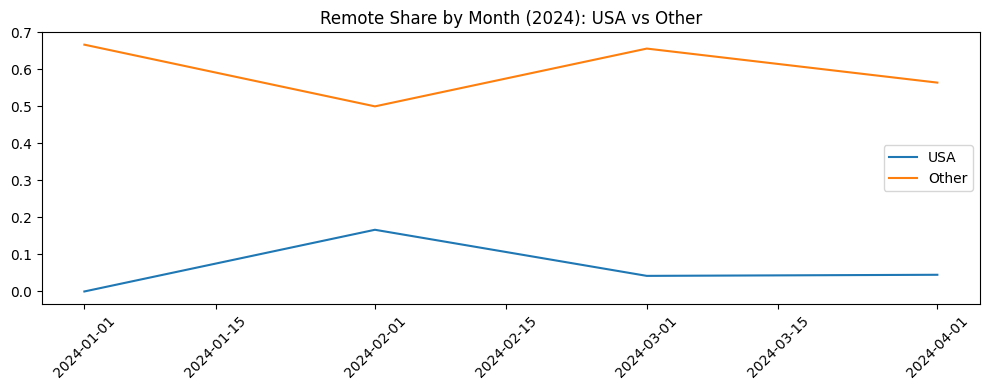

In [20]:
df_2024_all = df_2024_all.copy()  # already job-level

# Monthly (overall)
remote_month = df_2024_all.groupby("month").agg(
    total_posts=("job_id","nunique"),
    remote_posts=("is_remote","sum"),
).reset_index()

remote_month["remote_share"] = remote_month["remote_posts"] / remote_month["total_posts"]
display(remote_month)

plt.figure(figsize=(10,4))
plt.plot(remote_month["month"], remote_month["remote_share"])
plt.title("Remote Share by Month (2024 - Overall)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Quarterly (overall)
remote_quarter = df_2024_all.groupby("quarter").agg(
    total_posts=("job_id","nunique"),
    remote_posts=("is_remote","sum"),
).reset_index()
remote_quarter["remote_share"] = remote_quarter["remote_posts"] / remote_quarter["total_posts"]
display(remote_quarter)

plt.figure(figsize=(6,4))
plt.bar(remote_quarter["quarter"], remote_quarter["remote_share"])
plt.title("Remote Share by Quarter (2024 - Overall)")
plt.tight_layout()
plt.show()

# USA vs Other by month
remote_geo_month = df_2024_all.groupby(["location_transformed_refined","month"]).agg(
    total_posts=("job_id","nunique"),
    remote_posts=("is_remote","sum"),
).reset_index()
remote_geo_month["remote_share"] = remote_geo_month["remote_posts"] / remote_geo_month["total_posts"]

usa_line = remote_geo_month[remote_geo_month["location_transformed_refined"]=="USA"]
oth_line = remote_geo_month[remote_geo_month["location_transformed_refined"]=="Other"]

plt.figure(figsize=(10,4))
plt.plot(usa_line["month"], usa_line["remote_share"], label="USA")
plt.plot(oth_line["month"], oth_line["remote_share"], label="Other")
plt.title("Remote Share by Month (2024): USA vs Other")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### ✨ Improved Visualization (เพิ่มจากกราฟเดิม): Remote Trend (2024)

**แนวคิด/ความต่างจากกราฟเดิม**
- กราฟเดิม: แสดง line/bar แบบพื้นฐาน → อ่านแนวโน้มได้ แต่ยังไม่ชัดเรื่อง *ระดับเป็นเปอร์เซ็นต์*, *จุดสูง/ต่ำ*, และ *การเปลี่ยนแปลงจากต้นปี→ปลายปี*
- กราฟใหม่นี้:  
  1) แสดงแกน Y เป็น **เปอร์เซ็นต์** (Remote Share)  
  2) เติม **พื้นที่ (area)** + จุด marker เพื่ออ่านค่าแต่ละเดือนได้ง่าย  
  3) ใส่ **เส้นค่าเฉลี่ยเคลื่อนที่ (rolling avg)** และ **annotation** สรุปการเปลี่ยนแปลง (Δ)

> หมายเหตุ: Remote indicator ในโน้ตบุ๊กนี้อิงจาก **remote_allowed** (posting) เป็นหลัก

,period,remote_share,value
0,Start (first month),0.333333,33.3%
1,End (last month),0.121342,12.1%
2,Change (percentage points),NaN,-21.20 pp


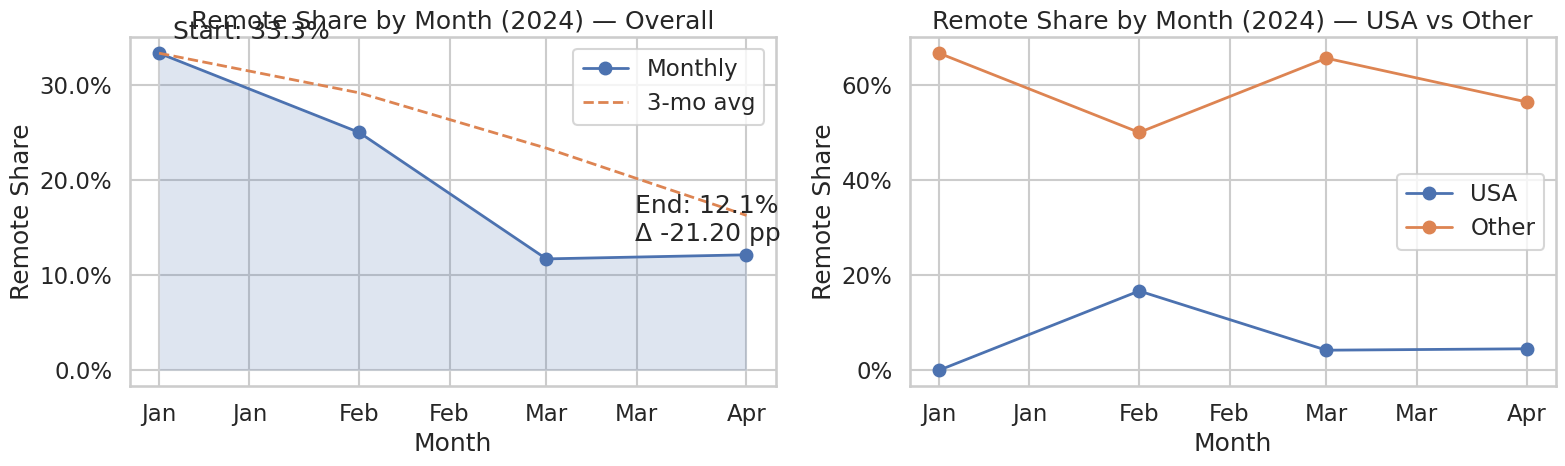

🔎 Interpretation (EN):
- Remote share ranges from 11.7% to 33.3% in 2024.
- Highest month: Jan (33.3%); Lowest month: Mar (11.7%).
- Overall change from first→last month: -21.20 percentage points.

🔎 คำอธิบาย (TH):
- สัดส่วนงาน Remote ในปี 2024 อยู่ในช่วง 11.7% ถึง 33.3%
- เดือนที่ Remote สูงสุด: Jan (33.3%) | ต่ำสุด: Mar (11.7%)
- การเปลี่ยนแปลงจากต้นปี→ปลายปี: -21.20 จุดเปอร์เซ็นต์ (pp)


In [21]:
# ========== Pretty Remote Trend Charts (2024) ==========
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import PercentFormatter
import matplotlib.dates as mdates

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="talk")
except Exception as e:
    print("seaborn not available, fallback to matplotlib only:", e)

# (re)compute if needed
if "remote_month" not in globals():
    remote_month = df_2024_all.groupby("month").agg(
        total_posts=("job_id","nunique"),
        remote_posts=("is_remote","sum"),
    ).reset_index()
    remote_month["remote_share"] = remote_month["remote_posts"] / remote_month["total_posts"]

remote_month = remote_month.sort_values("month").copy()

# Ensure datetime for nice formatting
if not np.issubdtype(remote_month["month"].dtype, np.datetime64):
    remote_month["month"] = pd.to_datetime(remote_month["month"])

# Rolling average (3 months)
remote_month["remote_share_ma3"] = remote_month["remote_share"].rolling(3, min_periods=1).mean()

# USA vs Other (monthly)
if "remote_geo_month" not in globals():
    remote_geo_month = df_2024_all.groupby(["location_transformed_refined","month"]).agg(
        total_posts=("job_id","nunique"),
        remote_posts=("is_remote","sum"),
    ).reset_index()
    remote_geo_month["remote_share"] = remote_geo_month["remote_posts"] / remote_geo_month["total_posts"]

remote_geo_month = remote_geo_month.copy()
if not np.issubdtype(remote_geo_month["month"].dtype, np.datetime64):
    remote_geo_month["month"] = pd.to_datetime(remote_geo_month["month"])
remote_geo_month = remote_geo_month.sort_values(["location_transformed_refined","month"])

usa_line = remote_geo_month[remote_geo_month["location_transformed_refined"]=="USA"].copy()
oth_line = remote_geo_month[remote_geo_month["location_transformed_refined"]=="Other"].copy()

# Summary numbers for annotation
p0 = float(remote_month["remote_share"].iloc[0])
p1 = float(remote_month["remote_share"].iloc[-1])
delta_pp = (p1 - p0) * 100  # percentage points

summary_remote = pd.DataFrame({
    "period": ["Start (first month)", "End (last month)", "Change (percentage points)"],
    "remote_share": [p0, p1, np.nan],
    "value": [f"{p0:.1%}", f"{p1:.1%}", f"{delta_pp:+.2f} pp"]
})
display(summary_remote)

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (A) Overall remote share by month (area + MA)
ax = axes[0]
ax.fill_between(remote_month["month"], remote_month["remote_share"], alpha=0.18)
ax.plot(remote_month["month"], remote_month["remote_share"], marker="o", linewidth=2, label="Monthly")
ax.plot(remote_month["month"], remote_month["remote_share_ma3"], linestyle="--", linewidth=2, label="3-mo avg")

ax.set_title("Remote Share by Month (2024) — Overall")
ax.set_xlabel("Month")
ax.set_ylabel("Remote Share")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="best")

# annotate start/end
ax.annotate(f"Start: {p0:.1%}", xy=(remote_month["month"].iloc[0], p0),
            xytext=(10, 10), textcoords="offset points")
ax.annotate(f"End: {p1:.1%}\nΔ {delta_pp:+.2f} pp", xy=(remote_month["month"].iloc[-1], p1),
            xytext=(-80, 10), textcoords="offset points",
            ha="left")

# (B) USA vs Other
ax = axes[1]
if len(usa_line) > 0:
    ax.plot(usa_line["month"], usa_line["remote_share"], marker="o", linewidth=2, label="USA")
if len(oth_line) > 0:
    ax.plot(oth_line["month"], oth_line["remote_share"], marker="o", linewidth=2, label="Other")

ax.set_title("Remote Share by Month (2024) — USA vs Other")
ax.set_xlabel("Month")
ax.set_ylabel("Remote Share")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="best")

plt.tight_layout()
plt.show()

# --- Auto-insights (ข้อความอธิบายอัตโนมัติ) ---
rm = remote_month.copy()
max_row = rm.loc[rm["remote_share"].idxmax()]
min_row = rm.loc[rm["remote_share"].idxmin()]

print("🔎 Interpretation (EN):")
print(f"- Remote share ranges from {min_row['remote_share']:.1%} to {max_row['remote_share']:.1%} in 2024.")
print(f"- Highest month: {max_row['month']:%b} ({max_row['remote_share']:.1%}); Lowest month: {min_row['month']:%b} ({min_row['remote_share']:.1%}).")
print(f"- Overall change from first→last month: {delta_pp:+.2f} percentage points.")

print("\n🔎 คำอธิบาย (TH):")
print(f"- สัดส่วนงาน Remote ในปี 2024 อยู่ในช่วง {min_row['remote_share']:.1%} ถึง {max_row['remote_share']:.1%}")
print(f"- เดือนที่ Remote สูงสุด: {max_row['month']:%b} ({max_row['remote_share']:.1%}) | ต่ำสุด: {min_row['month']:%b} ({min_row['remote_share']:.1%})")
print(f"- การเปลี่ยนแปลงจากต้นปี→ปลายปี: {delta_pp:+.2f} จุดเปอร์เซ็นต์ (pp)")

## 5.5 Salary Comparison (2024): Remote vs Non-Remote

**EN:** We compare `normalized_salary` between Remote and Non-Remote jobs.  
We remove missing/invalid salary values and summarize using median/mean and boxplots.  
We also split results by geography (USA vs Other).

**TH:** เปรียบเทียบ `normalized_salary` ระหว่างงาน Remote และ Non-Remote  
ตัดค่าเงินเดือนที่หาย/ผิดปกติ และสรุปด้วย median/mean และ boxplot  
พร้อมแยกผลตามพื้นที่ (USA vs Other)

> Salary coverage is partial; we report coverage as a limitation.

,total_unique_jobs_2024,jobs_with_salary,salary_coverage_%
0,122130,35550,29.108327


,remote_label,n,median,mean
0,Non-Remote,30805,77500.0,201587.018483
1,Remote,4745,113100.0,242788.648900


,location_transformed_refined,remote_label,n,median,mean
0,Other,Non-Remote,2716,97500.0,229635.166872
1,Other,Remote,3305,112500.0,122494.534629
2,USA,Non-Remote,28089,75000.0,198874.968534
3,USA,Remote,1440,114400.0,518880.348667


/tmp/ipython-input-257/2904351051.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Remote","Non-Remote"], showfliers=False)


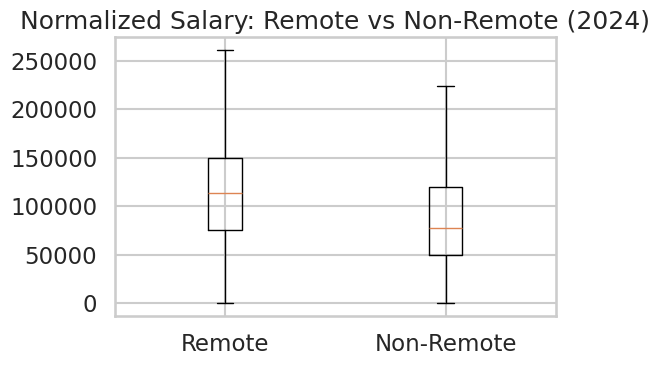

/tmp/ipython-input-257/2904351051.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=order, showfliers=False)


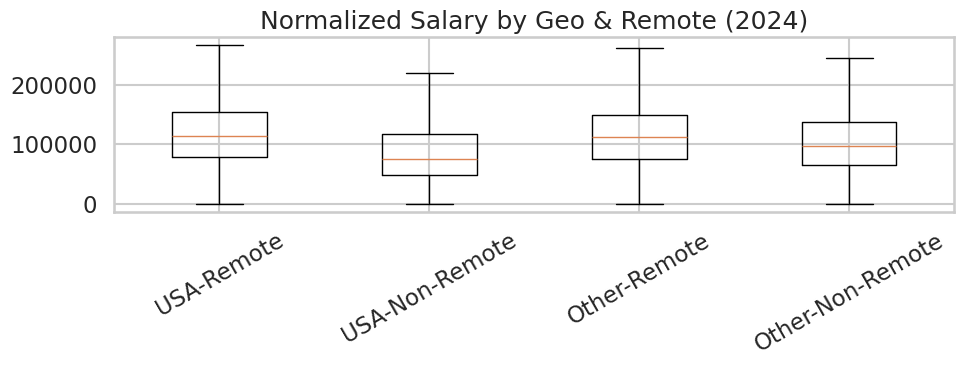

In [22]:
salary_df = df_2024_all[df_2024_all["normalized_salary"].notna()].copy()
salary_df = salary_df[salary_df["normalized_salary"] > 0].copy()

coverage = pd.DataFrame({
    "total_unique_jobs_2024": [df_2024_all["job_id"].nunique()],
    "jobs_with_salary": [salary_df["job_id"].nunique()],
})
coverage["salary_coverage_%"] = coverage["jobs_with_salary"] / coverage["total_unique_jobs_2024"] * 100
display(coverage)

salary_df["remote_label"] = np.where(salary_df["is_remote"], "Remote", "Non-Remote")

summary_remote = salary_df.groupby("remote_label")["normalized_salary"].agg(
    n="count", median="median", mean="mean"
).reset_index()
display(summary_remote)

summary_geo = salary_df.groupby(["location_transformed_refined","remote_label"])["normalized_salary"].agg(
    n="count", median="median", mean="mean"
).reset_index()
display(summary_geo)

# Boxplot overall
data = [
    salary_df[salary_df["remote_label"]=="Remote"]["normalized_salary"],
    salary_df[salary_df["remote_label"]=="Non-Remote"]["normalized_salary"],
]
plt.figure(figsize=(6,4))
plt.boxplot(data, labels=["Remote","Non-Remote"], showfliers=False)
plt.title("Normalized Salary: Remote vs Non-Remote (2024)")
plt.tight_layout()
plt.show()

# Boxplot 4 groups
salary_df["group"] = salary_df["location_transformed_refined"] + "-" + salary_df["remote_label"]
order = ["USA-Remote","USA-Non-Remote","Other-Remote","Other-Non-Remote"]
plot_data = [salary_df[salary_df["group"]==g]["normalized_salary"] for g in order]

plt.figure(figsize=(10,4))
plt.boxplot(plot_data, labels=order, showfliers=False)
plt.title("Normalized Salary by Geo & Remote (2024)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### ✨ Improved Visualization (เพิ่มจากกราฟเดิม): Salary Distribution — Remote vs Non-Remote (2024)

**แนวคิด/ความต่างจากกราฟเดิม**
- กราฟเดิม: boxplot แบบพื้นฐาน → เห็น median/ช่วงกระจาย แต่ “รูปทรง distribution” ยังไม่ชัด (เช่น โหนก, หางยาว)
- กราฟใหม่นี้:
  1) เพิ่ม **Violin + Box** เพื่อเห็นทั้ง distribution และ summary ในภาพเดียว  
  2) เพิ่ม **Histogram (density)** เพื่อดูการกระจายแบบละเอียด  
  3) ใส่ **annotation** สรุปความต่างของ median (Remote vs Non-Remote)

> หมายเหตุ: ใช้ normalized_salary เฉพาะค่ามากกว่า 0 และไม่ว่าง (notna)

,group,n,median,mean
0,Remote,4745,113100.0,242788.648900
1,Non-Remote,30805,77500.0,201587.018483


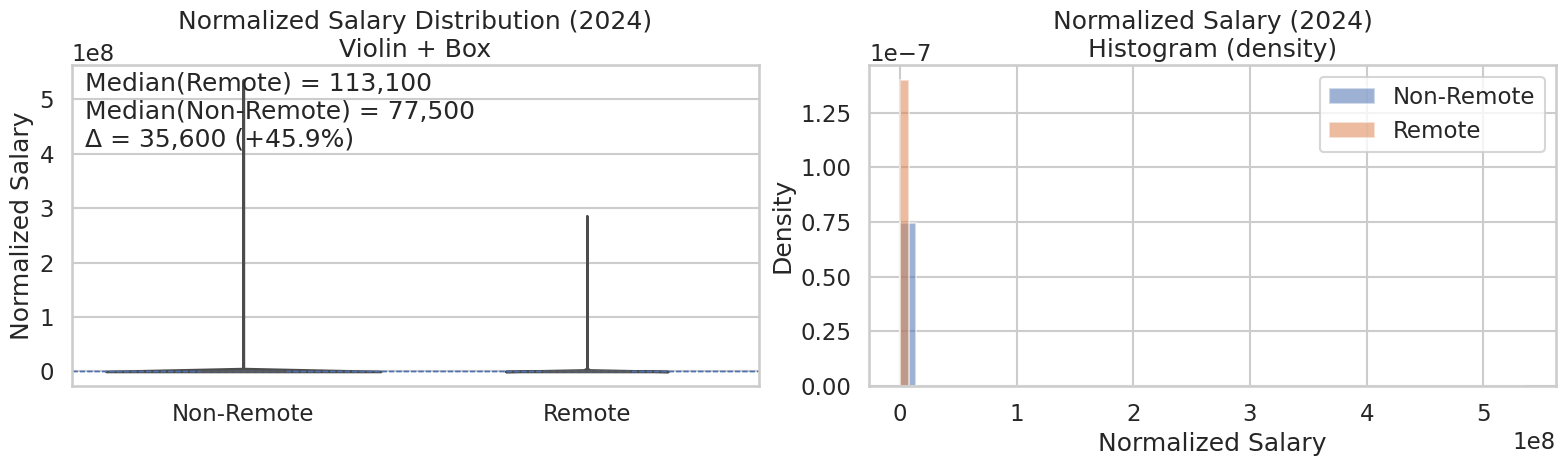

🔎 Interpretation (EN):
- Remote has higher median salary than Non-Remote by 35,600 (+45.9%).
- Use the violin shape to compare concentration (where salaries cluster) and tails (outliers).

🔎 คำอธิบาย (TH):
- กลุ่ม Remote มี median salary สูงกว่า Non-Remote ประมาณ 35,600 (+45.9%)
- รูปร่างของ violin ช่วยดูว่าเงินเดือนกระจุกตัวแถวไหน และมีหางยาว (ค่าที่สูงมาก) มากแค่ไหน


In [23]:
# ========== Pretty Salary Charts (2024): Remote vs Non-Remote ==========
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="talk")
except Exception as e:
    print("seaborn not available, fallback to matplotlib only:", e)

# Safety (if salary_df not created)
if "salary_df" not in globals():
    salary_df = df_2024_all[df_2024_all["normalized_salary"].notna()].copy()
    salary_df = salary_df[salary_df["normalized_salary"] > 0].copy()
    salary_df["remote_label"] = np.where(salary_df["is_remote"], "Remote", "Non-Remote")

# Basic stats
med_remote = salary_df.loc[salary_df["remote_label"]=="Remote", "normalized_salary"].median()
med_non   = salary_df.loc[salary_df["remote_label"]=="Non-Remote", "normalized_salary"].median()
diff_abs  = med_remote - med_non
diff_pct  = (diff_abs / med_non) * 100 if med_non and not np.isnan(med_non) else np.nan

stats = pd.DataFrame({
    "group": ["Remote", "Non-Remote"],
    "n": [int((salary_df["remote_label"]=="Remote").sum()), int((salary_df["remote_label"]=="Non-Remote").sum())],
    "median": [med_remote, med_non],
    "mean": [salary_df.loc[salary_df["remote_label"]=="Remote","normalized_salary"].mean(),
             salary_df.loc[salary_df["remote_label"]=="Non-Remote","normalized_salary"].mean()]
})
display(stats)

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (A) Violin + Box
ax = axes[0]
try:
    sns.violinplot(data=salary_df, x="remote_label", y="normalized_salary", inner=None, cut=0, ax=ax)
    sns.boxplot(data=salary_df, x="remote_label", y="normalized_salary", width=0.25, showfliers=False, ax=ax)
except Exception:
    # matplotlib fallback
    groups = [salary_df.loc[salary_df["remote_label"]=="Remote","normalized_salary"],
              salary_df.loc[salary_df["remote_label"]=="Non-Remote","normalized_salary"]]
    ax.violinplot(groups, showmeans=False, showmedians=True)
    ax.boxplot(groups, widths=0.25, showfliers=False)
    ax.set_xticks([1,2])
    ax.set_xticklabels(["Remote","Non-Remote"])

ax.set_title("Normalized Salary Distribution (2024)\nViolin + Box")
ax.set_xlabel("")
ax.set_ylabel("Normalized Salary")

# annotate medians
ax.axhline(med_remote, linestyle="--", linewidth=1)
ax.axhline(med_non, linestyle="--", linewidth=1)
ax.text(0.02, 0.98, f"Median(Remote) = {med_remote:,.0f}\nMedian(Non-Remote) = {med_non:,.0f}\nΔ = {diff_abs:,.0f} ({diff_pct:+.1f}%)",
        transform=ax.transAxes, va="top")

# (B) Histogram (density)
ax = axes[1]
bins = 40
remote_vals = salary_df.loc[salary_df["remote_label"]=="Remote","normalized_salary"]
non_vals    = salary_df.loc[salary_df["remote_label"]=="Non-Remote","normalized_salary"]

ax.hist(non_vals, bins=bins, alpha=0.55, density=True, label="Non-Remote")
ax.hist(remote_vals, bins=bins, alpha=0.55, density=True, label="Remote")

ax.set_title("Normalized Salary (2024)\nHistogram (density)")
ax.set_xlabel("Normalized Salary")
ax.set_ylabel("Density")
ax.legend(loc="best")

plt.tight_layout()
plt.show()

# --- Auto-insights (ข้อความอธิบายอัตโนมัติ) ---
print("🔎 Interpretation (EN):")
if med_remote > med_non:
    print(f"- Remote has higher median salary than Non-Remote by {diff_abs:,.0f} ({diff_pct:+.1f}%).")
else:
    print(f"- Remote has lower median salary than Non-Remote by {abs(diff_abs):,.0f} ({diff_pct:+.1f}%).")
print("- Use the violin shape to compare concentration (where salaries cluster) and tails (outliers).")

print("\n🔎 คำอธิบาย (TH):")
if med_remote > med_non:
    print(f"- กลุ่ม Remote มี median salary สูงกว่า Non-Remote ประมาณ {diff_abs:,.0f} ({diff_pct:+.1f}%)")
else:
    print(f"- กลุ่ม Remote มี median salary ต่ำกว่า Non-Remote ประมาณ {abs(diff_abs):,.0f} ({diff_pct:+.1f}%)")
print("- รูปร่างของ violin ช่วยดูว่าเงินเดือนกระจุกตัวแถวไหน และมีหางยาว (ค่าที่สูงมาก) มากแค่ไหน")

## 5.6 Skills Analysis (2024)

**EN:** We map skill IDs to skill names by joining `job_skills` with `skills`.  
Then we join skills with 2024 job postings to analyze:
1) Top demanded skills (frequency)
2) High-paying skills (median salary; apply minimum count threshold)
3) High-paying skills in Remote jobs only

**TH:** เราแปลงรหัสทักษะเป็นชื่อทักษะ โดย join `job_skills` กับ `skills`  
จากนั้น join กับประกาศงานปี 2024 เพื่อวิเคราะห์:
1) ทักษะที่ตลาดต้องการมาก (นับความถี่)
2) ทักษะที่สัมพันธ์กับเงินเดือนสูง (median salary + กำหนดขั้นต่ำจำนวนงาน)
3) ทักษะที่เงินเดือนสูงเฉพาะงาน Remote

In [24]:
# --- Helper: detect join key between job_skills and skills ---
def detect_skill_key(df_job_skills, df_skills):
    candidates = [("skill_id","skill_id"), ("skill_abr","skill_abr"), ("skill_abr","skill_id"), ("skill_id","skill_abr")]
    for a,b in candidates:
        if a in df_job_skills.columns and b in df_skills.columns:
            return a,b
    raise ValueError("Cannot detect skill join key. Please check columns in df_job_skills / df_skills.")

js_key, sk_key = detect_skill_key(df_job_skills, df_skills)
print("Using skill join keys:", js_key, "->", sk_key)

# 1) Map skill_name
job_skills_named = df_job_skills.merge(df_skills, left_on=js_key, right_on=sk_key, how="left")
# Expect a column 'skill_name'
if "skill_name" not in job_skills_named.columns:
    # sometimes column may be named differently; show columns for manual fix
    print("Columns in job_skills_named:", job_skills_named.columns.tolist())
    raise ValueError("Missing skill_name. Please identify correct column name in skills table.")
job_skills_named = job_skills_named.dropna(subset=["skill_name"]).copy()

# 2) Join with job-level 2024 postings
skills_2024 = df_2024_all[["job_id","is_remote","location_transformed_refined","normalized_salary"]].merge(
    job_skills_named[["job_id","skill_name"]],
    on="job_id",
    how="inner"
)

print("skills_2024 rows:", len(skills_2024), "unique jobs:", skills_2024["job_id"].nunique())
display(skills_2024.head())

Using skill join keys: skill_abr -> skill_abr
skills_2024 rows: 203167 unique jobs: 120590


,job_id,is_remote,location_transformed_refined,normalized_salary,skill_name
0,921716,False,USA,38480.0,Marketing
1,921716,False,USA,38480.0,Sales
2,10998357,False,USA,55000.0,Management
3,10998357,False,USA,55000.0,Manufacturing
4,23221523,False,USA,157500.0,Other


,skill_name,count
0,Information Technology,25005
1,Sales,20834
2,Management,20122
3,Manufacturing,17509
4,Health Care Provider,16503
5,Business Development,13051
6,Engineering,12425
7,Other,12250
8,Finance,7903
9,Marketing,5323


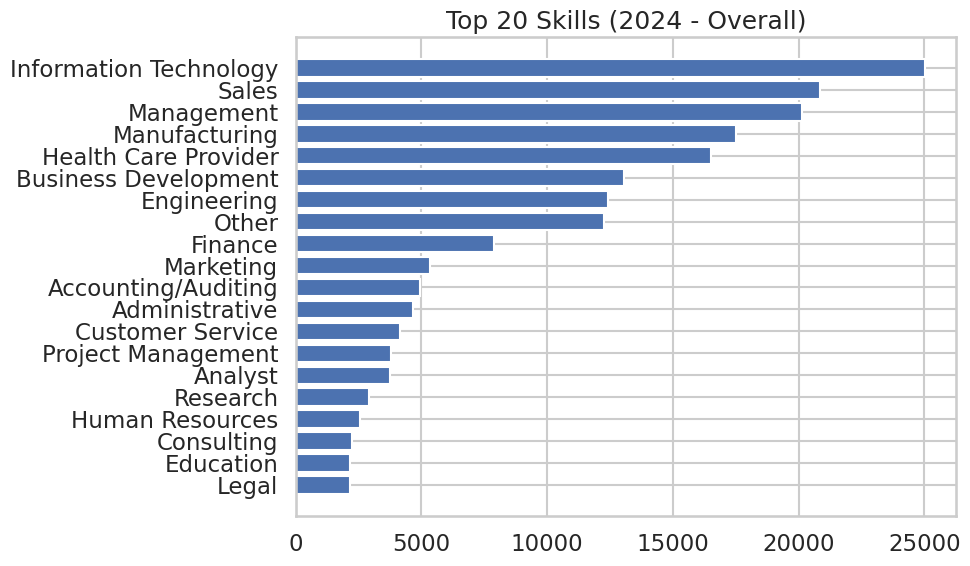

In [25]:
top_skills = skills_2024["skill_name"].value_counts().head(20).reset_index()
top_skills.columns = ["skill_name","count"]
display(top_skills)

plt.figure(figsize=(10,6))
plt.barh(top_skills["skill_name"][::-1], top_skills["count"][::-1])
plt.title("Top 20 Skills (2024 - Overall)")
plt.tight_layout()
plt.show()

,skill_name,n_jobs,median,mean
22,Product Management,469,140500.00,144662.062356
31,Strategy/Planning,464,120321.75,130611.765086
17,Legal,960,120000.00,892300.443510
11,Engineering,3745,120000.00,318068.409152
6,Consulting,789,114400.00,130490.163371
24,Project Management,1425,114400.00,117933.707267
16,Information Technology,7105,112500.00,297770.287714
2,Advertising,233,94050.00,101866.211159
28,Research,925,93600.00,112906.981568
3,Analyst,1256,93030.00,101997.362655


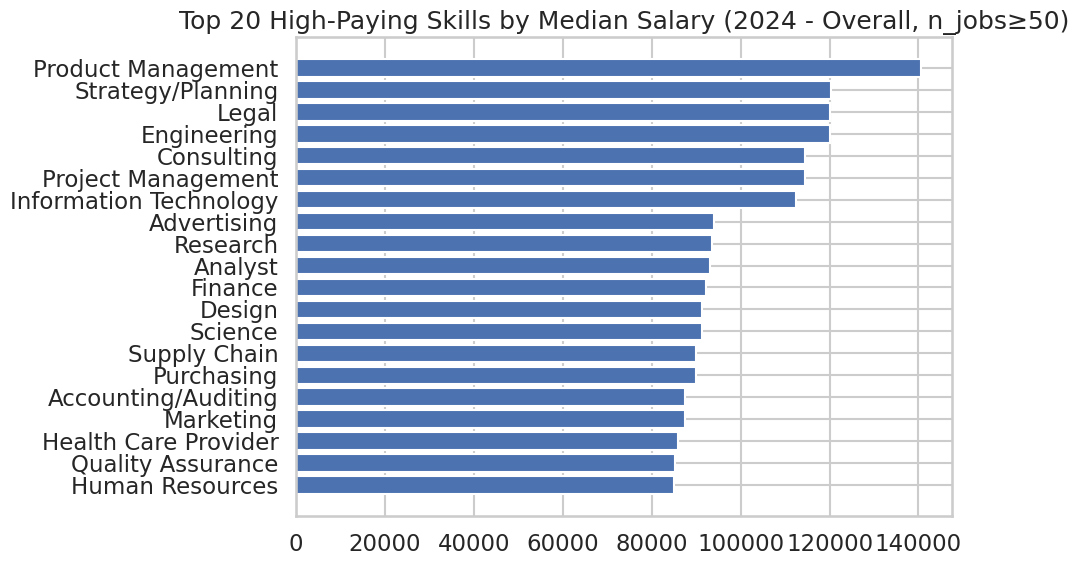

In [26]:
skill_salary = skills_2024.dropna(subset=["normalized_salary"]).copy()
skill_salary = skill_salary[skill_salary["normalized_salary"] > 0].copy()

skill_stats = (skill_salary.groupby("skill_name")
               .agg(
                   n_jobs=("job_id","nunique"),
                   median=("normalized_salary","median"),
                   mean=("normalized_salary","mean")
               )
               .reset_index()
              )

min_jobs = 50
skill_stats_filtered = (skill_stats[skill_stats["n_jobs"] >= min_jobs]
                        .sort_values("median", ascending=False)
                        .head(20))

display(skill_stats_filtered)

plt.figure(figsize=(10,6))
plt.barh(skill_stats_filtered["skill_name"][::-1], skill_stats_filtered["median"][::-1])
plt.title(f"Top 20 High-Paying Skills by Median Salary (2024 - Overall, n_jobs≥{min_jobs})")
plt.tight_layout()
plt.show()

,skill_name,n_jobs,median,mean
30,Science,44,145300.0,163945.281818
11,Engineering,587,145000.0,148584.872411
22,Product Management,119,136800.0,146249.920168
6,Consulting,206,135000.0,167118.326699
17,Legal,133,135000.0,149592.469925
31,Strategy/Planning,65,135000.0,146377.476923
16,Information Technology,1433,130000.0,531723.772324
32,Supply Chain,31,127500.0,121090.016129
28,Research,114,123650.0,135192.521579
14,Health Care Provider,214,119100.0,133239.775537


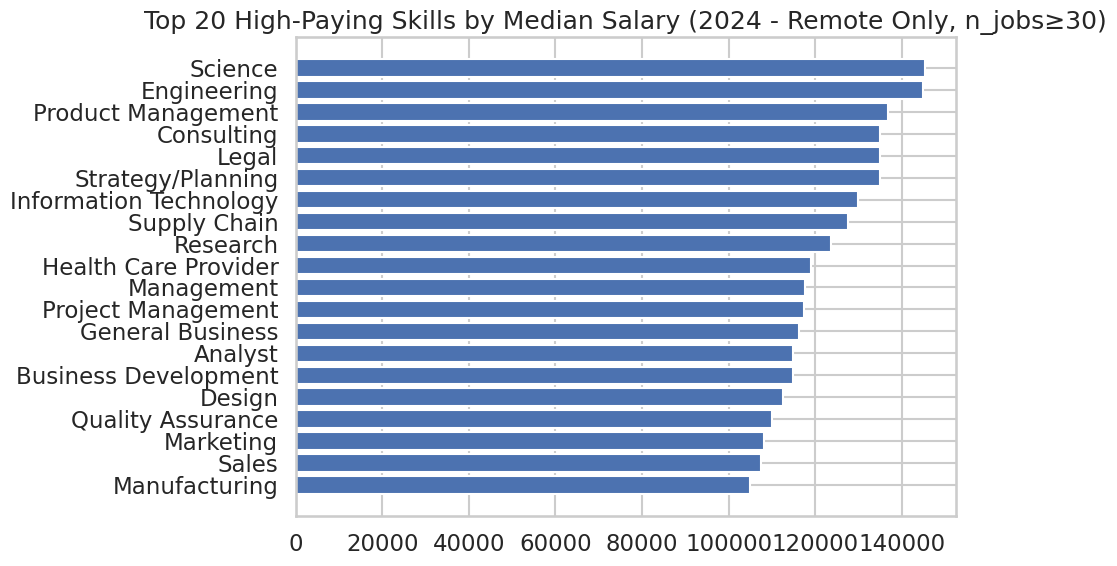

In [27]:
remote_only = skill_salary[skill_salary["is_remote"]].copy()

remote_skill_stats = (remote_only.groupby("skill_name")
                      .agg(
                          n_jobs=("job_id","nunique"),
                          median=("normalized_salary","median"),
                          mean=("normalized_salary","mean")
                      )
                      .reset_index()
                     )

min_jobs_remote = 30
remote_skill_stats_filtered = (remote_skill_stats[remote_skill_stats["n_jobs"] >= min_jobs_remote]
                               .sort_values("median", ascending=False)
                               .head(20))

display(remote_skill_stats_filtered)

plt.figure(figsize=(10,6))
plt.barh(remote_skill_stats_filtered["skill_name"][::-1], remote_skill_stats_filtered["median"][::-1])
plt.title(f"Top 20 High-Paying Skills by Median Salary (2024 - Remote Only, n_jobs≥{min_jobs_remote})")
plt.tight_layout()
plt.show()

### ✨ Improved Visualization (เพิ่มจากกราฟเดิม): Skills × Salary × Remote (2024)

**แนวคิด/ความต่างจากกราฟเดิม**
- กราฟเดิม: bar chart แยก “Top skills” และ “High-paying skills” → อ่านได้ แต่ยังไม่เห็น *trade-off* ระหว่าง
  - ความนิยม (จำนวนงานที่พบ skill นั้น)  
  - รายได้ (median salary)  
  - ความเป็น Remote (remote share)
- กราฟใหม่นี้: ทำเป็น **Bubble Scatter**  
  - แกน X = จำนวนงาน (n_jobs)  
  - แกน Y = median salary  
  - ขนาด bubble = n_jobs  
  - สี = remote share (ยิ่งเข้มยิ่ง remote มาก)

> ช่วยให้เห็นภาพรวมว่า “สกิลไหนทั้งนิยม + เงินดี + remote สูง” ในกราฟเดียว

,skill_name,n_jobs,median_salary,remote_share
16,Information Technology,25005,112500.0,0.184003
29,Sales,20834,75000.0,0.177210
18,Management,20122,59280.0,0.036776
19,Manufacturing,17509,54741.0,0.025073
14,Health Care Provider,16503,85976.8,0.037630
5,Business Development,13051,76788.0,0.199372
11,Engineering,12425,120000.0,0.169819
21,Other,12250,58500.0,0.071265
12,Finance,7903,92175.0,0.122359
20,Marketing,5323,87256.0,0.212850


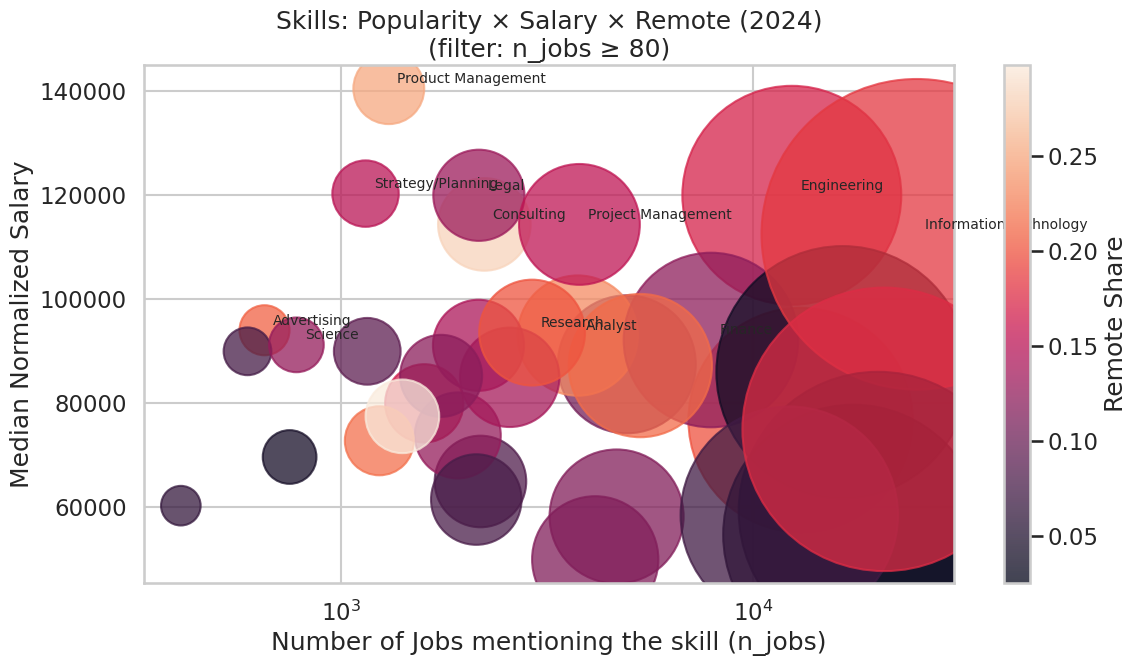

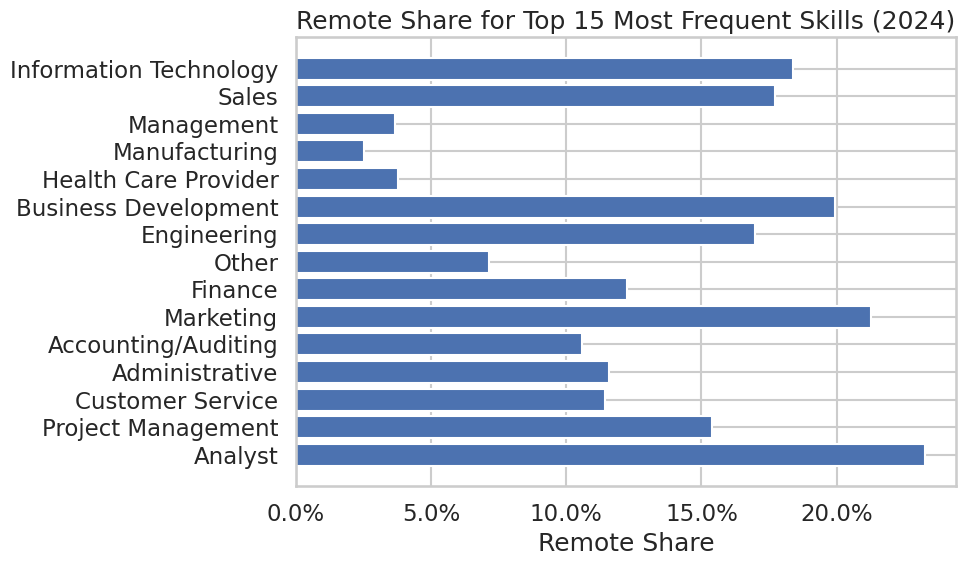

🔎 Interpretation (EN):
- Bubble chart helps spot skills that are BOTH popular (right), high-paying (up), and remote-friendly (color).
- Readability tip: because X is log-scaled, a small move right can mean a big jump in job counts.

Top 5 popular skills (by n_jobs):


,skill_name,n_jobs,median_salary,remote_share
16,Information Technology,25005,112500.0,0.184003
29,Sales,20834,75000.0,0.177210
18,Management,20122,59280.0,0.036776
19,Manufacturing,17509,54741.0,0.025073
14,Health Care Provider,16503,85976.8,0.037630



Top 5 high-paying skills (by median salary):


,skill_name,n_jobs,median_salary,remote_share
22,Product Management,1303,140500.00,0.251727
31,Strategy/Planning,1144,120321.75,0.150350
11,Engineering,12425,120000.00,0.169819
17,Legal,2157,120000.00,0.131664
24,Project Management,3786,114400.00,0.153724



Top 5 most remote-friendly among popular skills (filtered):


,skill_name,n_jobs,median_salary,remote_share
34,Writing/Editing,1406,77500.0,0.298009
6,Consulting,2224,114400.0,0.281924
22,Product Management,1303,140500.0,0.251727
3,Analyst,3751,93030.0,0.232471
25,Public Relations,1236,72800.0,0.216019



🔎 คำอธิบาย (TH):
- Bubble chart ช่วยเห็น ‘สกิลที่นิยม (ไปทางขวา) + เงินดี (สูงขึ้น) + Remote สูง (สีเข้ม)’ ในกราฟเดียว
- แกน X เป็น log scale: ขยับไปทางขวาเล็กน้อย อาจหมายถึงจำนวนงานเพิ่มขึ้นมาก


In [28]:
# ========== Pretty Skill Bubble Chart (2024) ==========
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
import numpy as np

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="talk")
except Exception as e:
    print("seaborn not available, fallback to matplotlib only:", e)

# Build skill summary (job-level count + median salary + remote share)
skill_bubble = (skills_2024
                .dropna(subset=["skill_name"])
                .groupby("skill_name")
                .agg(
                    n_jobs=("job_id","nunique"),
                    median_salary=("normalized_salary","median"),
                    remote_share=("is_remote","mean"),
                )
                .reset_index()
               )

# keep meaningful rows
skill_bubble = skill_bubble.dropna(subset=["median_salary"]).copy()
skill_bubble = skill_bubble[skill_bubble["median_salary"] > 0].copy()

min_jobs_bubble = 80  # ปรับได้
skill_bubble_f = skill_bubble[skill_bubble["n_jobs"] >= min_jobs_bubble].copy()

# pick top for labeling (high median among popular)
label_df = (skill_bubble_f
            .sort_values(["median_salary","n_jobs"], ascending=False)
            .head(12)
           )

display(skill_bubble_f.sort_values("n_jobs", ascending=False).head(10))

# ---- Bubble plot ----
fig, ax = plt.subplots(figsize=(12, 7))

sizes = skill_bubble_f["n_jobs"] * 2.0  # scale bubble size
sc = ax.scatter(skill_bubble_f["n_jobs"], skill_bubble_f["median_salary"],
                s=sizes, c=skill_bubble_f["remote_share"], alpha=0.75)

ax.set_title(f"Skills: Popularity × Salary × Remote (2024)\n(filter: n_jobs ≥ {min_jobs_bubble})")
ax.set_xlabel("Number of Jobs mentioning the skill (n_jobs)")
ax.set_ylabel("Median Normalized Salary")
ax.set_xscale("log")  # ทำให้เห็นช่วง n_jobs ชัดขึ้น

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Remote Share")

# label a few standout skills
for _, r in label_df.iterrows():
    ax.annotate(r["skill_name"], (r["n_jobs"], r["median_salary"]),
                textcoords="offset points", xytext=(6, 4), fontsize=10)

plt.tight_layout()
plt.show()

# Optional: Remote share for top skills (frequency)
topN = 15
top_freq = (skills_2024.groupby("skill_name")
            .agg(n_jobs=("job_id","nunique"),
                 remote_share=("is_remote","mean"))
            .reset_index()
            .sort_values("n_jobs", ascending=False)
            .head(topN)
           )

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_freq["skill_name"][::-1], top_freq["remote_share"][::-1])
ax.set_title(f"Remote Share for Top {topN} Most Frequent Skills (2024)")
ax.set_xlabel("Remote Share")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.show()

# --- Auto-insights (ข้อความอธิบายอัตโนมัติ) ---
# Popular skills
top_pop = skill_bubble.sort_values("n_jobs", ascending=False).head(10)
top_pay = skill_bubble.sort_values(["median_salary","n_jobs"], ascending=False).head(10)
top_remote = skill_bubble_f.sort_values(["remote_share","n_jobs"], ascending=False).head(10) if len(skill_bubble_f) else pd.DataFrame()

print("🔎 Interpretation (EN):")
print("- Bubble chart helps spot skills that are BOTH popular (right), high-paying (up), and remote-friendly (color).")
print("- Readability tip: because X is log-scaled, a small move right can mean a big jump in job counts.")
print("\nTop 5 popular skills (by n_jobs):")
display(top_pop.head(5))
print("\nTop 5 high-paying skills (by median salary):")
display(top_pay.head(5))
if len(top_remote):
    print("\nTop 5 most remote-friendly among popular skills (filtered):")
    display(top_remote.head(5))

print("\n🔎 คำอธิบาย (TH):")
print("- Bubble chart ช่วยเห็น ‘สกิลที่นิยม (ไปทางขวา) + เงินดี (สูงขึ้น) + Remote สูง (สีเข้ม)’ ในกราฟเดียว")
print("- แกน X เป็น log scale: ขยับไปทางขวาเล็กน้อย อาจหมายถึงจำนวนงานเพิ่มขึ้นมาก")

## Key Findings & Conclusion

**EN:** We summarize key insights from:
1) Remote trend (overall + USA vs Other)  
2) Salary differences (Remote vs Non-Remote; plus geo split)  
3) Skill demand vs compensation (top skills; high-paying skills; remote-only high-paying skills)

**Limitations (EN):**
- Salary coverage is partial (not all jobs report salary).
- Applies may be missing for many jobs.
- Industry mapping is many-to-many (a job can belong to multiple industries).
- Location normalization is coarse (USA vs Other).

**TH:** สรุปประเด็นสำคัญจาก:
1) แนวโน้ม Remote (รวม + เปรียบเทียบ USA vs Other)  
2) ความต่างของเงินเดือน (Remote vs Non-Remote และแยกพื้นที่)  
3) ความต้องการด้านทักษะและความสัมพันธ์กับค่าตอบแทน (Top skills / High-paying / Remote-only)

**ข้อจำกัด (TH):**
- ข้อมูลเงินเดือนไม่ครบทุกงาน (salary coverage)
- ข้อมูล applies ขาดหายจำนวนมาก
- งานหนึ่งอาจถูกจัดอยู่หลายอุตสาหกรรม (many-to-many)
- การแบ่ง location เป็น USA vs Other เป็นการจัดกลุ่มแบบหยาบ

In [29]:
# Quick numbers for writing the conclusion
remote_overall_2024 = df_2024_all["is_remote"].mean()
salary_cov = float(coverage["salary_coverage_%"].iloc[0])

print(f"Remote share (2024 overall): {remote_overall_2024:.2%}")
print(f"Salary coverage (2024): {salary_cov:.2f}%")

# Salary median comparison
meds = summary_remote.set_index("remote_label")["median"].to_dict()
print("Median salary Remote:", meds.get("Remote"))
print("Median salary Non-Remote:", meds.get("Non-Remote"))

Remote share (2024 overall): 12.13%
Salary coverage (2024): 29.11%
Median salary Remote: 113100.0
Median salary Non-Remote: 77500.0
